<a href="https://colab.research.google.com/github/gongyu-wang/IDX-Exchange-project-work/blob/main/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and Imports

In [1]:
import os
import os.path
import time
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Loading and Concatenation

In [2]:
os.getcwd()

'/content'

In [3]:
data_path = '/content/drive/My Drive/IDX Exchange/Data/'

In [4]:
s202605 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202605.csv'))
s202604 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202604.csv'))
s202603 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202603.csv'))
s202602 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202602.csv'))
s202601 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202601.csv'))
s202512 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202512.csv'))
s202511 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202511.csv'))
s202510 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202510.csv'))
s202509 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202509.csv'))
s202508 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202508.csv'))
s202507 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202507.csv'))
s202506 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202506.csv'))
s202505 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202505.csv'))
s202504 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202504.csv'))
s202503 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202503.csv'))
s202502 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202502.csv'))
s202501 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202501.csv'))

/tmp/ipykernel_2080/4100359550.py:6: DtypeWarning: Columns (4,60) have mixed types. Specify dtype option on import or set low_memory=False.
  s202512 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202512.csv'))
/tmp/ipykernel_2080/4100359550.py:12: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  s202506 = pd.read_csv(os.path.join(data_path, 'CRMLSSold202506.csv'))


In [5]:
data_frames = [
    s202605, s202604, s202603, s202602, s202601,
    s202512, s202511, s202510, s202509, s202508,
    s202507, s202506, s202505, s202504, s202503,
    s202502, s202501
]
data = pd.concat(data_frames, ignore_index=True)

## Initial Data Overview

In [6]:
data.shape

(342747, 80)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342747 entries, 0 to 342746
Data columns (total 80 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 337283 non-null  object 
 1   ListAgentAOR                  342610 non-null  object 
 2   Flooring                      201694 non-null  object 
 3   ViewYN                        308902 non-null  object 
 4   WaterfrontYN                  196 non-null     object 
 5   BasementYN                    5629 non-null    object 
 6   PoolPrivateYN                 305309 non-null  object 
 7   OriginalListPrice             341722 non-null  float64
 8   ListingKey                    342747 non-null  int64  
 9   ListAgentEmail                341683 non-null  object 
 10  CloseDate                     342747 non-null  object 
 11  ClosePrice                    342743 non-null  float64
 12  ListAgentFirstName            341089 non-nul

## Data Filtering

In [8]:
data["PropertyType"].value_counts()

,count
PropertyType,
Residential,226973
ResidentialLease,84063
Land,10406
ResidentialIncome,8922
ManufacturedInPark,8593
CommercialSale,1951
CommercialLease,1662
BusinessOpportunity,177


In [9]:
data["PropertySubType"].value_counts()

,count
PropertySubType,
SingleFamilyResidence,209924
Condominium,59905
Townhouse,19707
Apartment,8830
Duplex,6651
ManufacturedOnLand,3369
Triplex,2144
Quadruplex,2109
StockCooperative,1102


In [10]:
data = data[(data['PropertyType'] == 'Residential') & (data['PropertySubType'] == 'SingleFamilyResidence')]

In [11]:
data.shape

(170660, 80)

## Numerical Feature Analysis

In [13]:
data.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [15]:
num_cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
]

data[num_cols].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,1.706600e+05,170567.000000,170660.000000,170640.000000,1.676200e+05
mean,1.332291e+06,2040.125906,3.486540,2.625387,3.229995e+05
std,7.285189e+06,1037.944058,0.966481,1.134163,1.699608e+07
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,6.300000e+05,1383.000000,3.000000,2.000000,5.663000e+03
50%,8.990000e+05,1811.000000,3.000000,2.000000,7.260000e+03
75%,1.431000e+06,2430.000000,4.000000,3.000000,1.040000e+04
max,9.895000e+08,56500.000000,45.000000,45.000000,2.087221e+09


## Visualizing Numerical Features - Boxplots

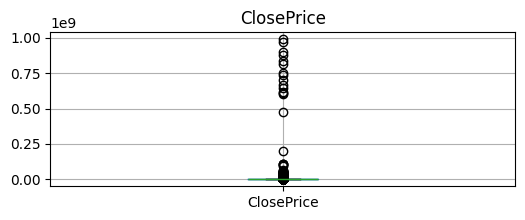

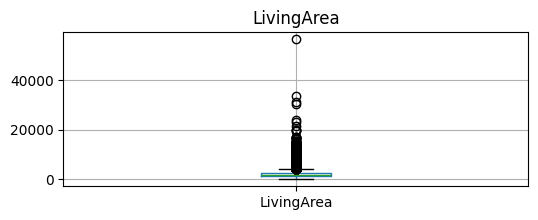

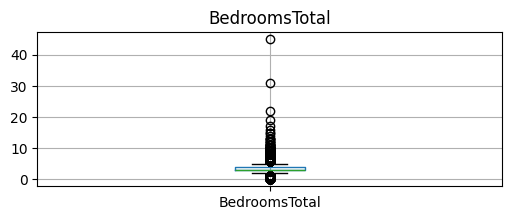

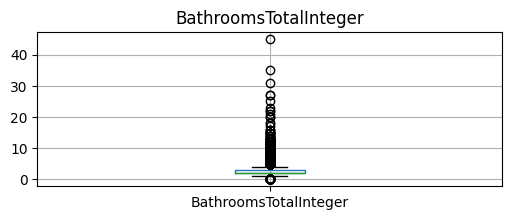

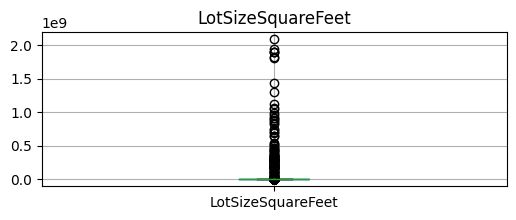

In [38]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6,2))
    data.boxplot(column=col)
    plt.title(col)
    plt.show()

## Visualizing Numerical Features - Histograms

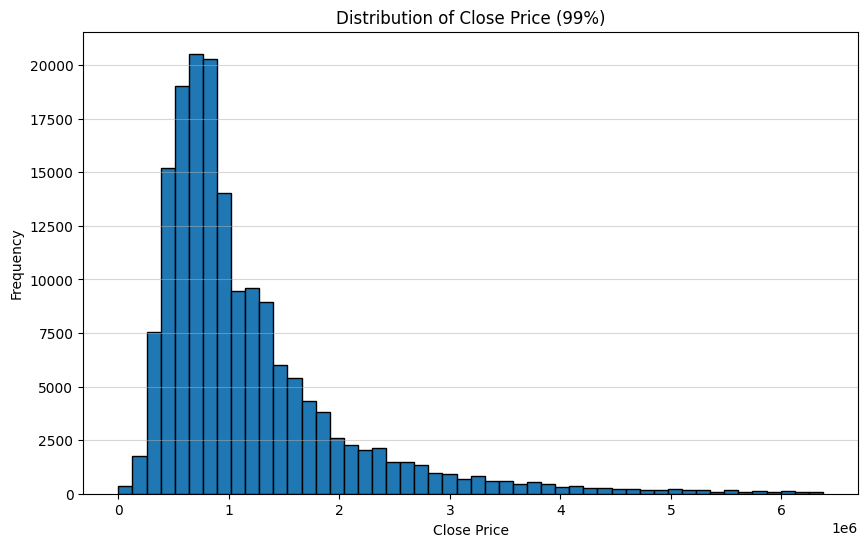

In [25]:
import matplotlib.pyplot as plt

upper = data["ClosePrice"].quantile(0.99)
close_price = data[data["ClosePrice"] <= upper]["ClosePrice"]

plt.figure(figsize=(10,6))
plt.hist(close_price, bins=50, edgecolor='black')
plt.title("Distribution of Close Price (99%)")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.show()

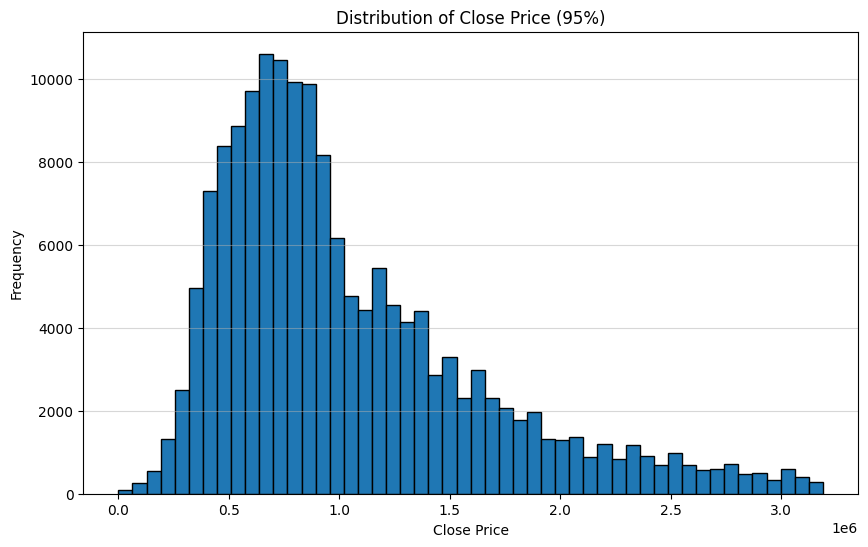

In [24]:
import matplotlib.pyplot as plt

upper = data["ClosePrice"].quantile(0.95)
close_price = data[data["ClosePrice"] <= upper]["ClosePrice"]

plt.figure(figsize=(10,6))
plt.hist(close_price, bins=50, edgecolor='black')
plt.title("Distribution of Close Price (95%)")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.show()

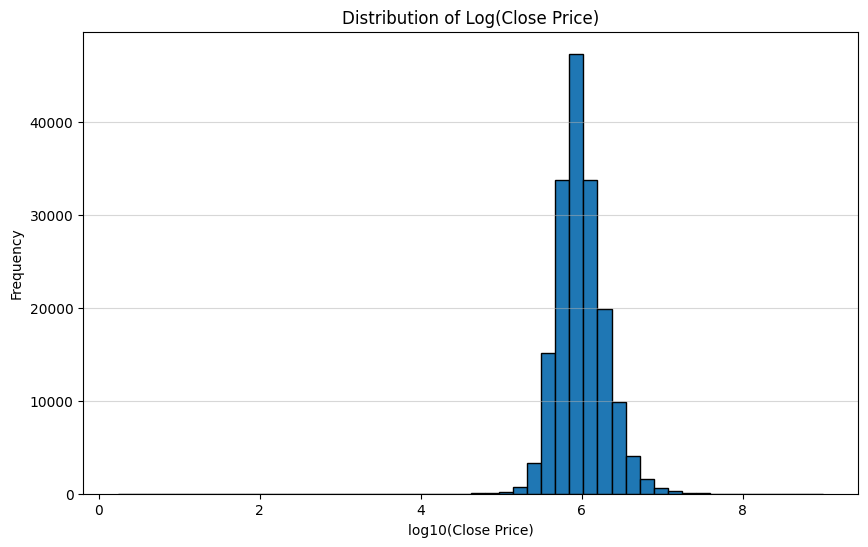

In [22]:
close_price = data[data["ClosePrice"] > 0]["ClosePrice"]

plt.figure(figsize=(10,6))
plt.hist(np.log10(close_price), bins=50, edgecolor='black')

plt.title("Distribution of Log(Close Price)")
plt.xlabel("log10(Close Price)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.show()

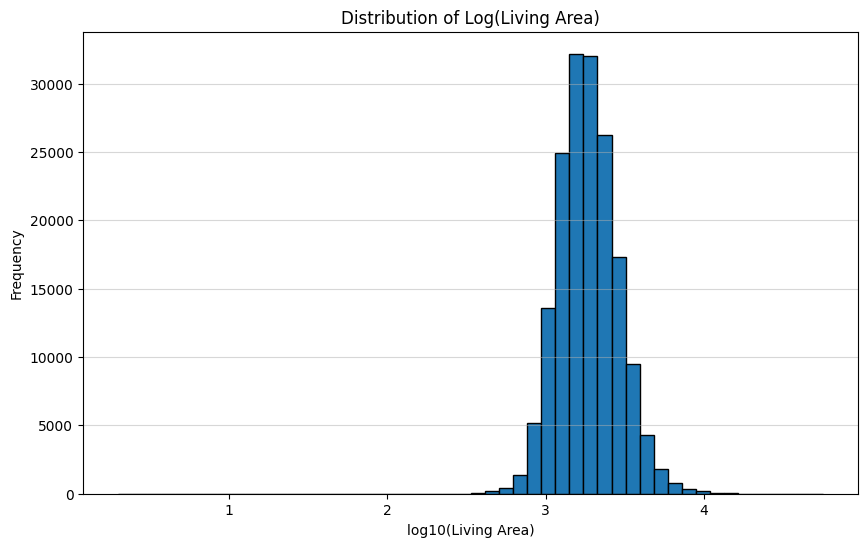

In [27]:
living_area = data[data["LivingArea"] > 0]["LivingArea"]

plt.figure(figsize=(10,6))
plt.hist(np.log10(living_area), bins=50, edgecolor='black')
plt.title("Distribution of Log(Living Area)")
plt.xlabel("log10(Living Area)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.show()

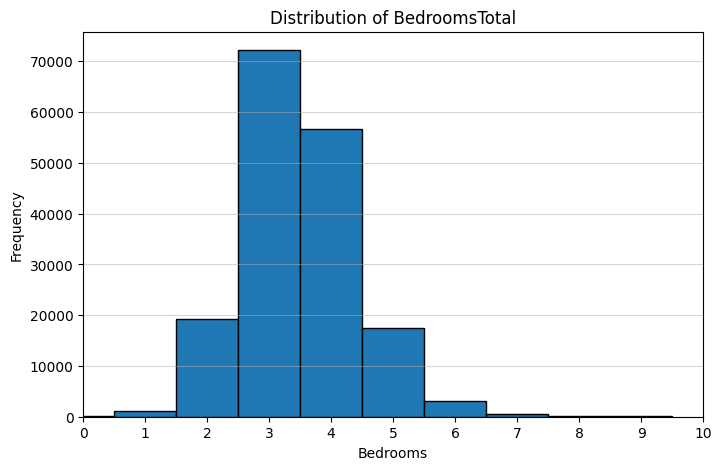

In [34]:
plt.figure(figsize=(8,5))
plt.hist(
    data["BedroomsTotal"],
    bins=range(0, 11),
    edgecolor='black',
    align='left'
)

plt.xlim(0,10)

plt.title("Distribution of BedroomsTotal")
plt.xlabel("Bedrooms")
plt.ylabel("Frequency")
plt.xticks(range(0,11))
plt.grid(axis='y', alpha=0.5)
plt.show()

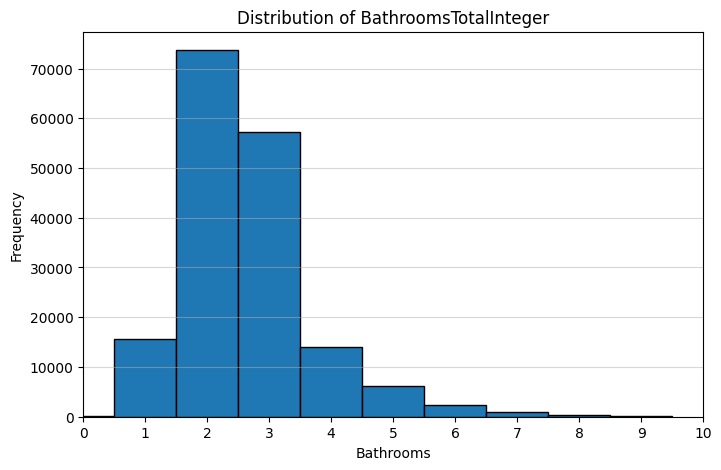

In [35]:
plt.figure(figsize=(8,5))
plt.hist(
    data["BathroomsTotalInteger"],
    bins=range(0, 11),
    edgecolor='black',
    align='left'
)

plt.xlim(0,10)

plt.title("Distribution of BathroomsTotalInteger")
plt.xlabel("Bathrooms")
plt.ylabel("Frequency")
plt.xticks(range(0,11))
plt.grid(axis='y', alpha=0.5)
plt.show()

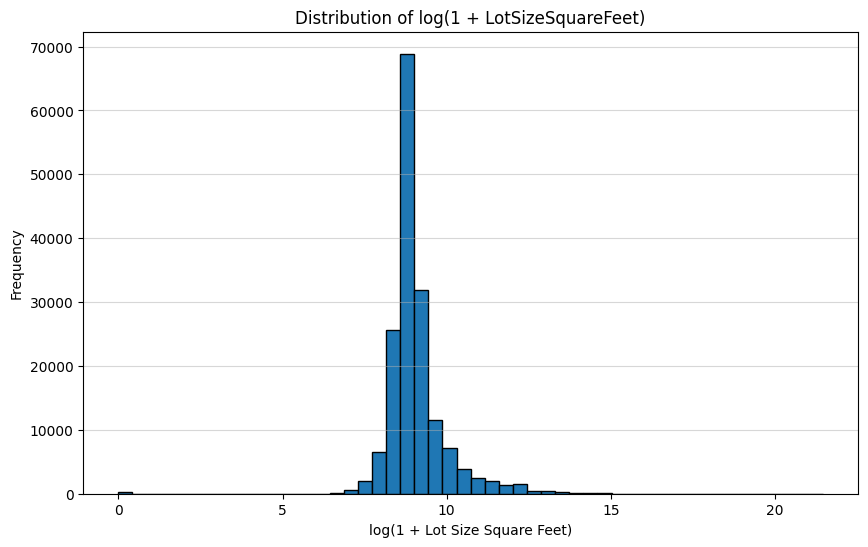

In [37]:
lot = data["LotSizeSquareFeet"].dropna()

plt.figure(figsize=(10,6))
plt.hist(np.log1p(lot), bins=50, edgecolor='black')

plt.title("Distribution of log(1 + LotSizeSquareFeet)")
plt.xlabel("log(1 + Lot Size Square Feet)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)

plt.show()